# Disaster Tweets — gradient-boosted trees on latent topics and engineered features

Linear models see a tweet as a bag of independent words. Trees can combine a few strong, differently-scaled signals and
learn interactions (a high-risk keyword *and* a link *and* no mention). The features come from the data-understanding notebook:

| Group | Features | Why |
|---|---|---|
| Latent topics | 100 components of a truncated SVD of word 1–2-gram TF-IDF (latent semantic analysis) | dense summary of vocabulary |
| Keyword | empirical-Bayes **shrunk keyword rate**, target-encoded *inside* the training fold | keyword alone gives AUC 0.79 |
| Surface | characters, words, URLs, hashtags, mentions, upper-case ratio, digits, `!`, `?`, location given | effect sizes up to r = 0.3 in the EDA |

**No leakage:** SVD and vocabulary are fitted on each fold's training rows; the keyword encoding of a *training* row is computed
from the other inner folds, so a row never sees its own label. Early stopping uses an inner 10% of the training rows; the
outer validation fold is only *watched* (log loss every 10 trees) and never selects anything.

In [1]:
import time, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import log_loss, roc_auc_score, roc_curve
import nlp_common as N
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52", "#55A868", "#8172B2"]
train, test, folds = N.load(); y = train.target.values
Xt, Tt = N.model_text(train), N.model_text(test)

def surface(df):
    t = df.text
    return pd.DataFrame({"chars": t.str.len(), "words": t.str.split().str.len(), "urls": t.str.count(r"https?://\S+"), "hashtags": t.str.count(r"#\w+"),
        "mentions": t.str.count(r"@\w+"), "upper_ratio": t.apply(lambda s: sum(c.isupper() for c in s) / max(1, sum(c.isalpha() for c in s))),
        "digits": t.str.count(r"\d"), "exclaim": t.str.count("!"), "question": t.str.count(r"\?"), "has_location": df.location.notna().astype(int)}, index=df.index)
S_tr, S_te = surface(train), surface(test)
kw_tr, kw_te = train.keyword.fillna("none"), test.keyword.fillna("none")

def kw_map(kw, yy):
    g = pd.DataFrame({"k": kw.values, "y": yy}).groupby("k").y.agg(["sum", "count"]); r = g["sum"] / g["count"]
    m, v = r.mean(), max(r.var(), 1e-4); c = max(m * (1 - m) / v - 1, 1.0); a, b = m * c, (1 - m) * c
    return ((g["sum"] + a) / (g["count"] + a + b)).to_dict(), float(yy.mean())
def kw_encode(kw, mp, prior): return kw.map(mp).fillna(prior).values
def kw_oof(kw, yy, seed=0):
    out = np.zeros(len(kw))
    for tr, va in KFold(5, shuffle=True, random_state=seed).split(kw):
        mp, pr = kw_map(kw.iloc[tr], yy[tr]); out[va] = kw_encode(kw.iloc[va], mp, pr)
    return out
print("surface features:", list(S_tr.columns))

surface features: ['chars', 'words', 'urls', 'hashtags', 'mentions', 'upper_ratio', 'digits', 'exclaim', 'question', 'has_location']


In [2]:
PARAMS = dict(objective="binary", learning_rate=0.03, num_leaves=15, min_child_samples=25, feature_fraction=0.6, bagging_fraction=0.8, bagging_freq=1,
              lambda_l2=5.0, max_bin=127, verbose=-1, num_threads=12, seed=7)
FOLD = {}; t0 = time.time()
def run_fold(k):
    tr, va = np.where(folds != k)[0], np.where(folds == k)[0]
    tv = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True); A = tv.fit_transform(Xt.iloc[tr])
    svd = TruncatedSVD(100, random_state=7, algorithm="randomized", n_iter=4); Za = svd.fit_transform(A)
    Zv, Zt = svd.transform(tv.transform(Xt.iloc[va])), svd.transform(tv.transform(Tt))
    mp, pr = kw_map(kw_tr.iloc[tr], y[tr])
    def block(Z, S, kwe): return np.column_stack([Z, kwe, S.values])
    Fa = block(Za, S_tr.iloc[tr], kw_oof(kw_tr.iloc[tr], y[tr])); Fv = block(Zv, S_tr.iloc[va], kw_encode(kw_tr.iloc[va], mp, pr)); Ft = block(Zt, S_te, kw_encode(kw_te, mp, pr))
    names = [f"svd_{i}" for i in range(100)] + ["keyword_rate"] + list(S_tr.columns)
    i_tr, i_in = train_test_split(np.arange(len(tr)), test_size=0.1, stratify=y[tr], random_state=k)
    rec = {}
    m = lgb.train(PARAMS, lgb.Dataset(Fa[i_tr], y[tr][i_tr]), num_boost_round=1500, valid_sets=[lgb.Dataset(Fa[i_in], y[tr][i_in])], valid_names=["inner"],
                  callbacks=[lgb.early_stopping(60, verbose=False), lgb.record_evaluation(rec)])
    its = list(range(10, m.current_iteration() + 60, 10)); its = [i for i in its if i <= m.num_trees()] or [m.current_iteration()]
    mon = [(i, log_loss(y[va], m.predict(Fv, num_iteration=i)), roc_auc_score(y[va], m.predict(Fv, num_iteration=i))) for i in its]
    gain = pd.Series(m.feature_importance("gain"), index=names)
    return dict(va=va, pv=m.predict(Fv, num_iteration=m.best_iteration), pt=m.predict(Ft, num_iteration=m.best_iteration), best=m.best_iteration,
                inner_loss=rec["inner"]["binary_logloss"], mon=mon, gain=gain, Fv=Fv, names=names, model=m)
from concurrent.futures import ThreadPoolExecutor
PARAMS["num_threads"] = 3
with ThreadPoolExecutor(4) as ex: res = list(ex.map(run_fold, range(5)))
oof = np.zeros(len(y)); test_p = 0
for r in res: oof[r["va"]] = r["pv"]; test_p = test_p + r["pt"] / 5
ev = N.evaluate(y, oof, folds); print(f"GBDT: AUC {ev['auc']:.4f}  F1 {ev['f1']:.4f} {np.round(ev['f1_ci95'], 4)}  best iterations {[r['best'] for r in res]}  ({time.time()-t0:.0f}s)")
N.save_method("gbdt", oof, test_p, dict(kind="probability", best_iterations=[r["best"] for r in res], **ev))

GBDT: AUC 0.8482  F1 0.7480 [0.7379 0.759 ]  best iterations [296, 238, 316, 628, 364]  (32s)


## In-training view: boosting learning curves

Per fold: inner-holdout log loss at every tree (the early-stopping signal), and the outer fold's log loss and AUC every 10 trees
(watched only). The gap between the two shows how well the inner holdout predicts the outer fold.

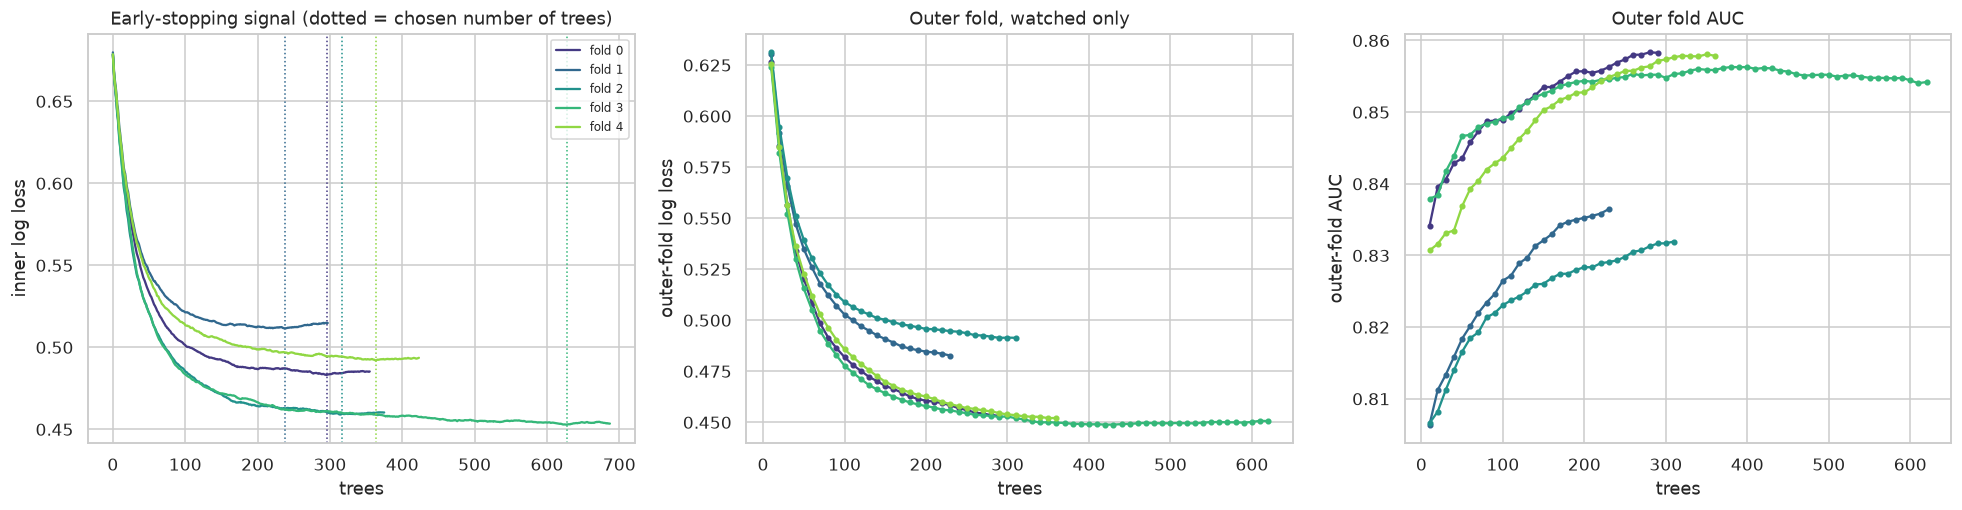

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8)); cs = sns.color_palette("viridis", 5)
for k, r in enumerate(res):
    axes[0].plot(r["inner_loss"], color=cs[k], label=f"fold {k}"); axes[0].axvline(r["best"], color=cs[k], ls=":", lw=1)
    it, ll, au = zip(*r["mon"]); axes[1].plot(it, ll, "o-", color=cs[k], ms=3); axes[2].plot(it, au, "o-", color=cs[k], ms=3)
axes[0].set_xlabel("trees"); axes[0].set_ylabel("inner log loss"); axes[0].set_title("Early-stopping signal (dotted = chosen number of trees)"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("trees"); axes[1].set_ylabel("outer-fold log loss"); axes[1].set_title("Outer fold, watched only")
axes[2].set_xlabel("trees"); axes[2].set_ylabel("outer-fold AUC"); axes[2].set_title("Outer fold AUC")
plt.tight_layout(); plt.savefig("assets/gbdt_01_learning_curves.png", bbox_inches="tight"); plt.show()

## Post-training: what the trees use

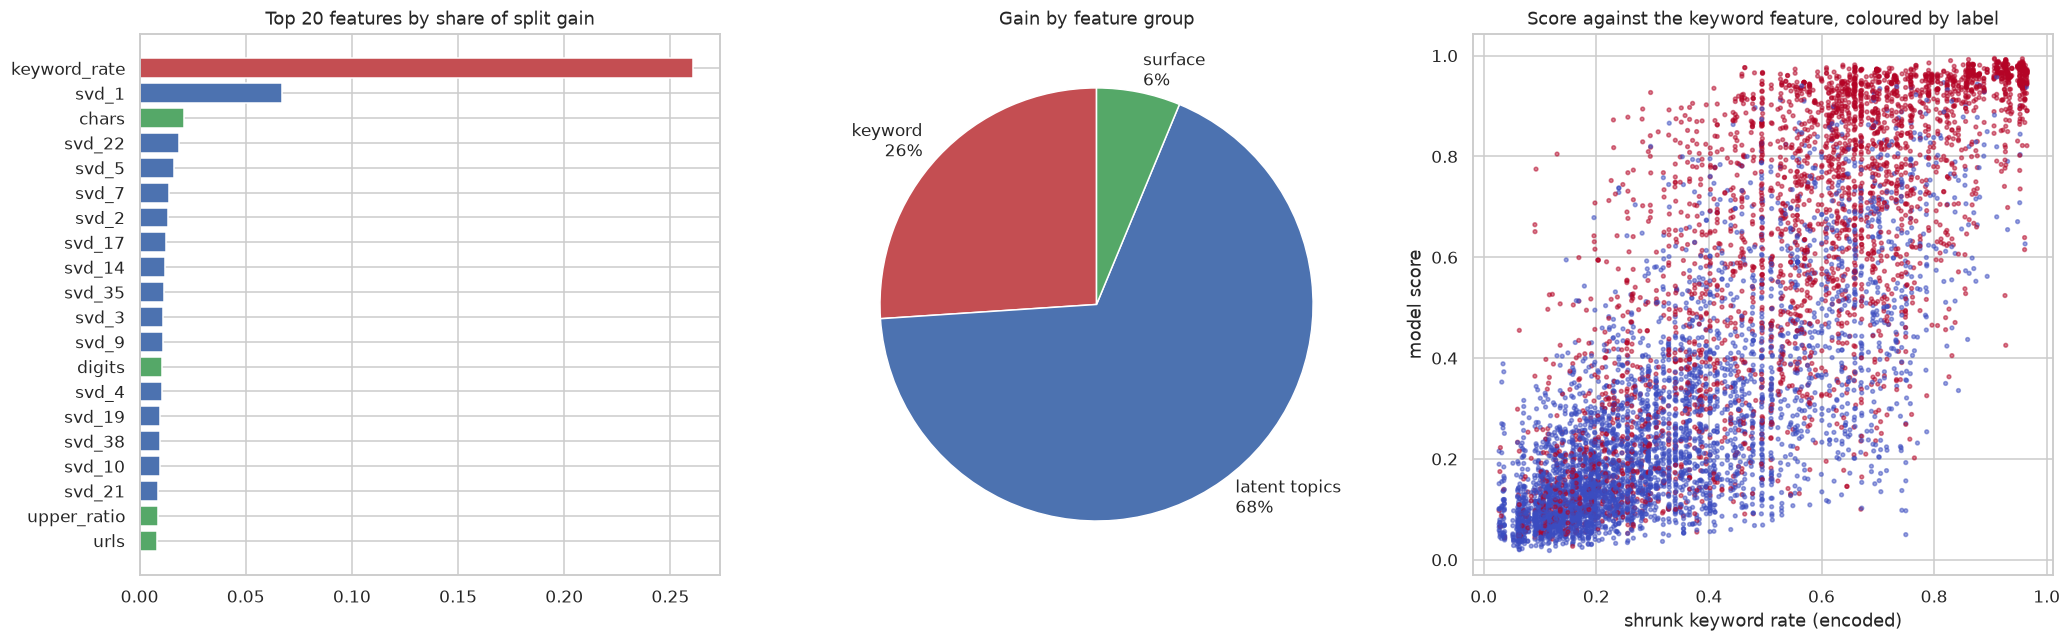

In [4]:
G = pd.concat([r["gain"] for r in res], axis=1).mean(1); G = G / G.sum(); grp = lambda n: "latent topics" if n.startswith("svd_") else ("keyword" if n == "keyword_rate" else "surface")
gg = G.groupby([grp(n) for n in G.index]).sum()
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
top = G.sort_values().tail(20); axes[0].barh(top.index, top.values, color=[{"keyword": PAL[1], "surface": PAL[2], "latent topics": PAL[0]}[grp(n)] for n in top.index]); axes[0].set_title("Top 20 features by share of split gain")
axes[1].pie(gg.values, labels=[f"{k}\n{v:.0%}" for k, v in gg.items()], colors=[PAL[1], PAL[0], PAL[2]] if list(gg.index) == ["keyword", "latent topics", "surface"] else None, startangle=90); axes[1].set_title("Gain by feature group")
Fv_all = np.vstack([r["Fv"] for r in res]); va_all = np.concatenate([r["va"] for r in res]); names = res[0]["names"]
kwi = names.index("keyword_rate"); sc = axes[2].scatter(Fv_all[:, kwi], oof[va_all], c=y[va_all], cmap="coolwarm", s=6, alpha=.5)
axes[2].set_xlabel("shrunk keyword rate (encoded)"); axes[2].set_ylabel("model score"); axes[2].set_title("Score against the keyword feature, coloured by label")
plt.tight_layout(); plt.savefig("assets/gbdt_02_feature_use.png", bbox_inches="tight"); plt.show()

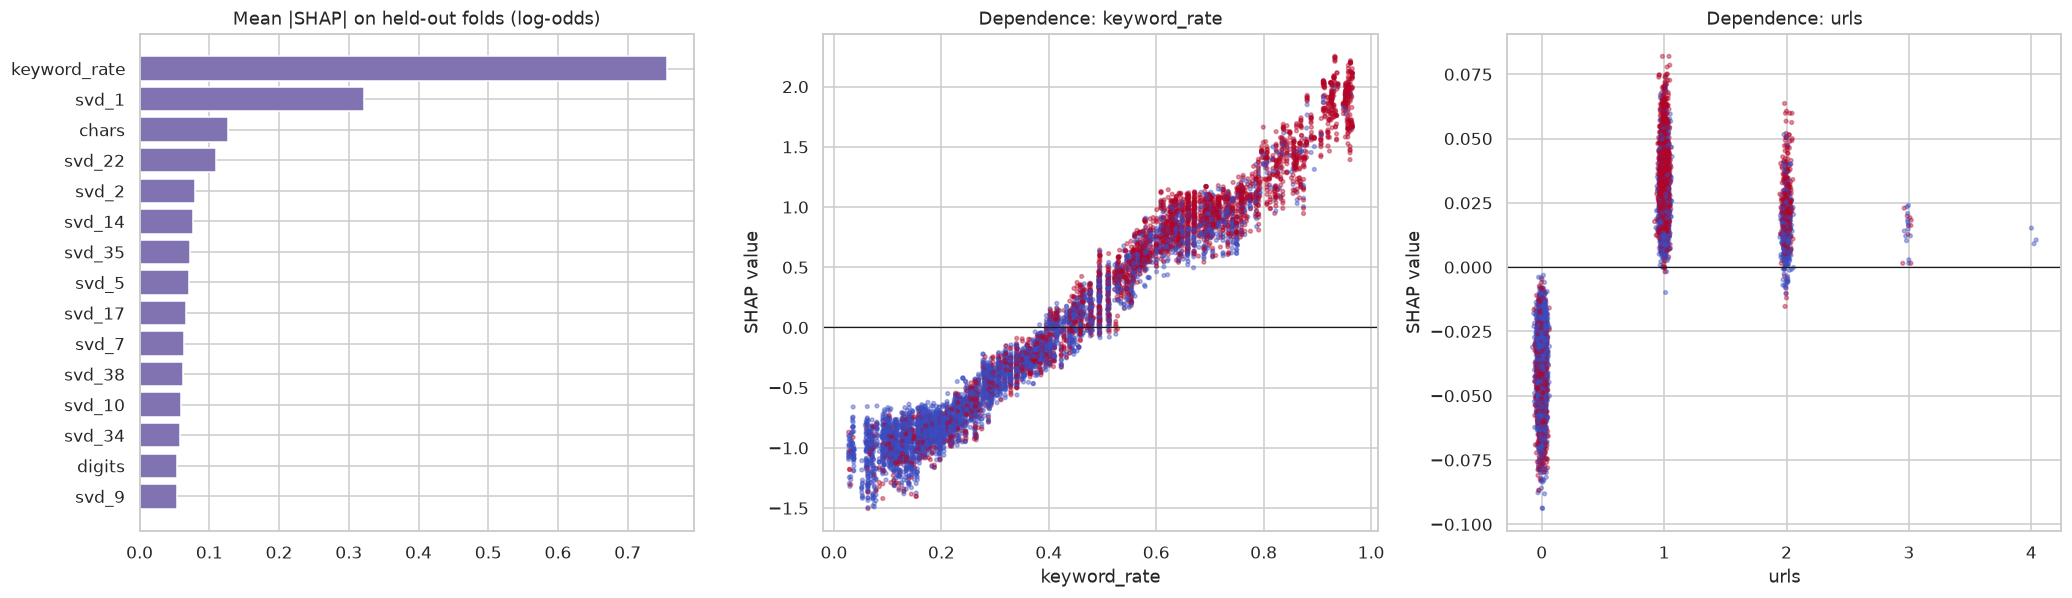

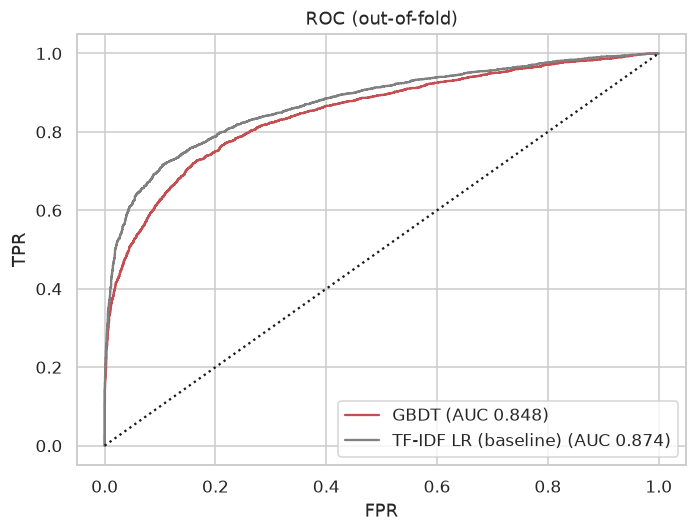

In [5]:
shap = np.vstack([r["model"].predict(r["Fv"], pred_contrib=True)[:, :-1] for r in res]); ms = pd.Series(np.abs(shap).mean(0), index=names).sort_values().tail(15)
fig, axes = plt.subplots(1, 3, figsize=(19, 5.6))
axes[0].barh(ms.index, ms.values, color=PAL[3]); axes[0].set_title("Mean |SHAP| on held-out folds (log-odds)")
for ax, f in zip(axes[1:], ["keyword_rate", "urls"]):
    j = names.index(f); ax.scatter(Fv_all[:, j] + np.random.default_rng(0).normal(0, 0.02 if f == "urls" else 0, len(Fv_all)), shap[:, j], s=6, alpha=.4, c=y[va_all], cmap="coolwarm")
    ax.axhline(0, color="k", lw=.8); ax.set_xlabel(f); ax.set_ylabel("SHAP value"); ax.set_title(f"Dependence: {f}")
plt.tight_layout(); plt.savefig("assets/gbdt_03_shap.png", bbox_inches="tight"); plt.show()
base = np.load("results/v1_tfidf_oof.npy"); fig, ax = plt.subplots(figsize=(6.5, 5))
for nm, o, c in [("GBDT", oof, PAL[1]), ("TF-IDF LR (baseline)", base, "grey")]:
    f, t, _ = roc_curve(y, o); ax.plot(f, t, color=c, label=f"{nm} (AUC {roc_auc_score(y, o):.3f})")
ax.plot([0, 1], [0, 1], "k:"); ax.legend(); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC (out-of-fold)")
plt.tight_layout(); plt.savefig("assets/gbdt_04_roc.png", bbox_inches="tight"); plt.show()